## Studi Kasus: Fuzzy Logic untuk Sistem Kontrol Dehumidifier

## 1. Import Library

Library yang digunakan dalam sistem fuzzy logic ini:

| Library | Fungsi |
|---|---|
| **NumPy** | Komputasi numerik dan array operations |
| **scikit-fuzzy (skfuzzy)** | Fungsi-fungsi fuzzy logic (membership, inference) |
| **Matplotlib** | Visualisasi grafik dan membership functions |
| **Pandas** | Manipulasi dan display data dalam tabel |

In [107]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd

## 2. Variabel Fuzzy

Sistem fuzzy logic ini memiliki:

### Input Variables
1. **Temperature (Suhu Ruangan)** 
   Rentang: 0–40°C

2. **Error Humidity (Kesalahan Kelembapan)**
   Formula: eH = RH_actual - RH_target
   Rentang: 0–40% (nilai positif menunjukkan kelembapan berlebih)

### Output Variable
1. **Compressor Power (Daya Kompressor)**
   Rentang: 0–100%

## 3. Mendefinisikan Universe of Discourse
Universe of Discourse = rentang nilai untuk setiap variabel fuzzy

In [108]:
temperature = ctrl.Antecedent(np.arange(0, 40, 0.1), 'temperature')
humidity_error = ctrl.Antecedent(np.arange(0, 40, 0.1), 'humidity_error')
compressor_power = ctrl.Consequent(np.arange(0, 100, 0.1), 'compressor_power')

print(f"  • Temperature    : {temperature.universe.min():.1f}°C - {temperature.universe.max():.0f}°C")
print(f"  • Humidity Error : {humidity_error.universe.min():.1f}% - {humidity_error.universe.max():.0f}%")
print(f"  • Compressor Power : {compressor_power.universe.min():.1f}% - {compressor_power.universe.max():.0f}%")

  • Temperature    : 0.0°C - 40°C
  • Humidity Error : 0.0% - 40%
  • Compressor Power : 0.0% - 100%


## 4. Membership Function - Input 1: Temperature

**Temperature** mewakili suhu ruangan saat ini.

| Fuzzy Set | Deskripsi | Range (°C) |
|---|---|---|
| **Very Cold** | Sangat dingin | 0–17 |
| **Cold** | Dingin | 18–21 |
| **Normal** | Suhu normal | 22–25 | 
| **Hot** | Panas | 27–30 | 
| **Very Hot** | Sangat panas | 31–40 |

In [109]:
temperature['Very Cold'] = fuzz.trapmf(temperature.universe, [0, 0, 15, 17])
temperature['Cold'] = fuzz.trapmf(temperature.universe, [15, 18, 20, 22])
temperature['Normal'] = fuzz.trapmf(temperature.universe, [20, 22, 25, 27])
temperature['Hot'] = fuzz.trapmf(temperature.universe, [25, 27, 30, 31])
temperature['Very Hot'] = fuzz.trapmf(temperature.universe, [30, 31, 40, 40])

## 5. Membership Function - Input 2: Error Humidity

**Error Humidity** = RH_actual - RH_target, menunjukkan seberapa jauh kelembapan aktual melebihi target.

| Fuzzy Set | Deskripsi | Range (%) |
|---|---|---|
| **Zero** (ZE) | Kelembapan pada target | 0–5 | 
| **Small Positive** (SP) | Sedikit di atas target | 6–9 |
| **Medium Positive** (MP) | Moderat di atas target | 10–19 |
| **Large Positive** (LP) | Jauh di atas target | 20–40 |

In [110]:
humidity_error['ZE'] = fuzz.trapmf(humidity_error.universe, [0, 0, 5, 6])
humidity_error['SP'] = fuzz.trapmf(humidity_error.universe, [5, 6, 9, 10])
humidity_error['MP'] = fuzz.trapmf(humidity_error.universe, [9, 10, 19, 20])
humidity_error['LP'] = fuzz.trapmf(humidity_error.universe, [19, 20, 40, 40])

## 6. Membership Functions - Output: Compressor Power

Daya kompressor yang diatur secara otomatis oleh fuzzy system.

| Level | Deskripsi | Range (%) |
|---|---|---|
| **Very Low** | Daya sangat rendah | 0 – 10 |
| **Low** | Daya rendah | 20 – 30 |
| **Medium** | Daya sedang | 40 – 60 |
| **High** | Daya tinggi | 70 – 80 |
| **Very High** | Daya sangat tinggi | 90 – 100 |

**Tipe Membership Function**: Trapezoidal

In [111]:
compressor_power['Very Low'] = fuzz.trapmf(compressor_power.universe, [0, 0, 10, 20])
compressor_power['Low'] = fuzz.trapmf(compressor_power.universe, [10, 20, 30, 40])
compressor_power['Medium'] = fuzz.trapmf(compressor_power.universe, [30, 40, 60, 70])
compressor_power['High'] = fuzz.trapmf(compressor_power.universe, [60, 70, 80, 90])
compressor_power['Very High'] = fuzz.trapmf(compressor_power.universe, [80, 90, 100, 100])

## 7. Visualisasi Membership Function

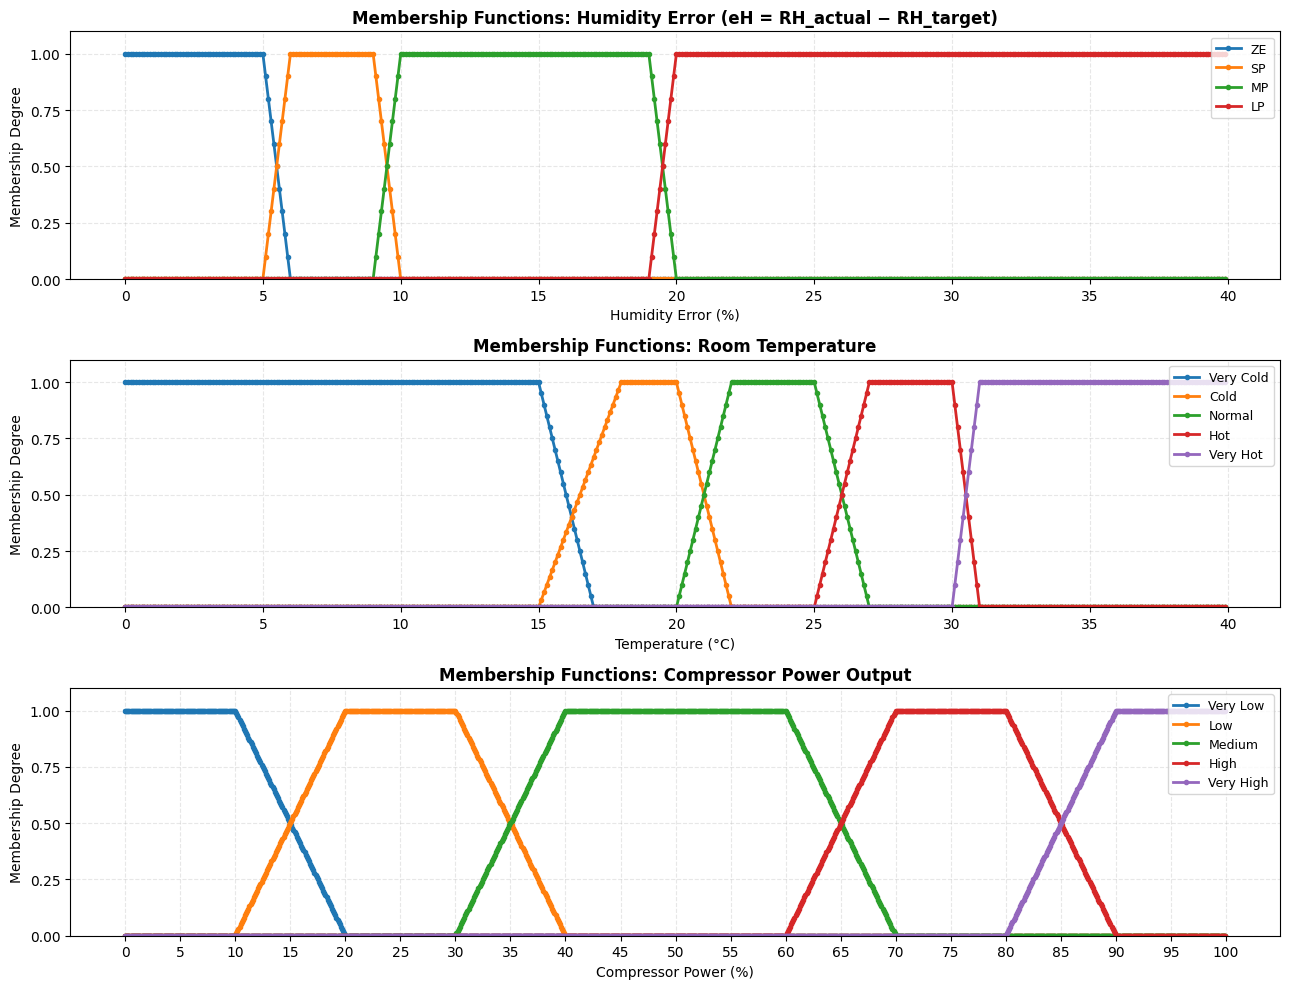

In [112]:
def visualize_membership_functions():
    fig, axes = plt.subplots(3, 1, figsize=(13, 10))

    # Plot 1: Humidity Error
    ax = axes[0]
    ax.set_title('Membership Functions: Humidity Error (eH = RH_actual − RH_target)', 
                 fontsize=12, fontweight='bold')
    for label in humidity_error.terms:
        if hasattr(humidity_error[label], 'mf'):
            ax.plot(humidity_error.universe, humidity_error[label].mf, 
                    label=label, linewidth=2, marker='.')
    ax.set_xlabel('Humidity Error (%)', fontsize=10)
    ax.set_ylabel('Membership Degree', fontsize=10)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

    # Plot 2: Temperature
    ax = axes[1]
    ax.set_title('Membership Functions: Room Temperature', 
                 fontsize=12, fontweight='bold')
    for label in temperature.terms:
        if hasattr(temperature[label], 'mf'):
            ax.plot(temperature.universe, temperature[label].mf, 
                    label=label, linewidth=2, marker='.')
    ax.set_xlabel('Temperature (°C)', fontsize=10)
    ax.set_ylabel('Membership Degree', fontsize=10)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

    # Plot 3: Compressor Power
    ax = axes[2]
    ax.set_title('Membership Functions: Compressor Power Output', 
                 fontsize=12, fontweight='bold')
    for label in compressor_power.terms:
        if hasattr(compressor_power[label], 'mf'):
            ax.plot(compressor_power.universe, compressor_power[label].mf, 
                    label=label, linewidth=2, marker='.')
    ax.set_xlabel('Compressor Power (%)', fontsize=10)
    ax.set_ylabel('Membership Degree', fontsize=10)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

    plt.tight_layout()
    plt.show()

def classify_power(value):
    if value < 15:
        return "Very Low"
    elif value < 35:
        return "Low"
    elif value < 55:
        return "Medium"
    elif value < 75:
        return "High"
    else:
        return "Very High"

visualize_membership_functions()

## 8. Fuzzy Rule Base
### Tabel Aturan Fuzzy

| Humidity Error | Very Cold | Cold | Normal | Hot | Very Hot |
|---|---|---|---|---|---|
| **Zero** | Very Low | Very Low | Very Low | Low | Low |
| **Small Positive** | Very Low | Low | Low | Medium | Medium |
| **Medium Positive** | Very Low | Medium | Medium | High | High |
| **Large Positive** | Very Low | High | High | Very High | Very High |


In [113]:
rules = [
    # ZE row
    ctrl.Rule(humidity_error['ZE'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Cold'],      compressor_power['Very Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Normal'],    compressor_power['Very Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Hot'],       compressor_power['Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Very Hot'],  compressor_power['Low']),

    # SP row
    ctrl.Rule(humidity_error['SP'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['SP'] & temperature['Cold'],      compressor_power['Low']),
    ctrl.Rule(humidity_error['SP'] & temperature['Normal'],    compressor_power['Low']),
    ctrl.Rule(humidity_error['SP'] & temperature['Hot'],       compressor_power['Medium']),
    ctrl.Rule(humidity_error['SP'] & temperature['Very Hot'],  compressor_power['Medium']),

    # MP row
    ctrl.Rule(humidity_error['MP'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['MP'] & temperature['Cold'],      compressor_power['Medium']),
    ctrl.Rule(humidity_error['MP'] & temperature['Normal'],    compressor_power['Medium']),
    ctrl.Rule(humidity_error['MP'] & temperature['Hot'],       compressor_power['High']),
    ctrl.Rule(humidity_error['MP'] & temperature['Very Hot'],  compressor_power['High']),

    # LP row
    ctrl.Rule(humidity_error['LP'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['LP'] & temperature['Cold'],      compressor_power['High']),
    ctrl.Rule(humidity_error['LP'] & temperature['Normal'],    compressor_power['High']),
    ctrl.Rule(humidity_error['LP'] & temperature['Hot'],       compressor_power['Very High']),
    ctrl.Rule(humidity_error['LP'] & temperature['Very Hot'],  compressor_power['Very High']),
]

## 9. Test Case

In [114]:
## Test Case
#RH_aktual, RH_target, Temp
test_cases = [
    (70, 50, 24),
    (80, 50, 26),
    (55, 50, 18),
]

## 10. Metode MAX
MAX method menggunakan operator MAX untuk kedua input variabel.

In [115]:
compressor_ctrl_max = ctrl.ControlSystem(rules)
compressor_sim_max = ctrl.ControlSystemSimulation(compressor_ctrl_max)

max_results = []

for rh_actual, rh_target, temp in test_cases:
    eH = rh_actual - rh_target
    eH_clamped = float(np.clip(eH, 0, 30))
    temp_clamped = float(np.clip(temp, 0, 40))
    
    compressor_sim_max.input['humidity_error'] = eH_clamped
    compressor_sim_max.input['temperature'] = temp_clamped
    compressor_sim_max.compute()
    power_max = compressor_sim_max.output['compressor_power']
    
    max_results.append({'eH': eH, 'Temp': temp, 'Power (%)': round(power_max, 2)})

df_max = pd.DataFrame(max_results)
print(df_max.to_string(index=False))

 eH  Temp  Power (%)
 20    24      75.00
 30    26      81.17
  5    18       7.78


## 11. Metode SUGENO

Sugeno method menggunakan pendekatan yang berbeda dari Mamdani. Output membership functions menggunakan fungsi linear atau konstanta.

### Tabel Aturan Sugeno

| Humidity Error | Very Cold | Cold | Normal | Hot | Very Hot |
|---|---|---|---|---|---|
| **Zero** | 5 | 5 | 5 | 15 | 20 |
| **Small Positive** | 5 | 20 | 25 | 40 | 50 |
| **Medium Positive** | 5 | 40 | 50 | 70 | 80 |
| **Large Positive** | 5 | 70 | 75 | 90 | 95 |


In [116]:
# Definisikan output membership functions sebagai konstanta
compressor_power_sugeno = ctrl.Consequent(np.arange(0, 100, 0.1), 'compressor_power_sugeno')

# Tambahkan membership functions sebagai konstanta
compressor_power_sugeno['5'] = fuzz.trimf(compressor_power_sugeno.universe, [5, 5, 5])
compressor_power_sugeno['15'] = fuzz.trimf(compressor_power_sugeno.universe, [15, 15, 15])
compressor_power_sugeno['20'] = fuzz.trimf(compressor_power_sugeno.universe, [20, 20, 20])
compressor_power_sugeno['25'] = fuzz.trimf(compressor_power_sugeno.universe, [25, 25, 25])
compressor_power_sugeno['40'] = fuzz.trimf(compressor_power_sugeno.universe, [40, 40, 40])
compressor_power_sugeno['50'] = fuzz.trimf(compressor_power_sugeno.universe, [50, 50, 50])
compressor_power_sugeno['70'] = fuzz.trimf(compressor_power_sugeno.universe, [70, 70, 70])
compressor_power_sugeno['75'] = fuzz.trimf(compressor_power_sugeno.universe, [75, 75, 75])
compressor_power_sugeno['80'] = fuzz.trimf(compressor_power_sugeno.universe, [80, 80, 80])
compressor_power_sugeno['90'] = fuzz.trimf(compressor_power_sugeno.universe, [90, 90, 90])
compressor_power_sugeno['95'] = fuzz.trimf(compressor_power_sugeno.universe, [95, 95, 95])

# Buat rules untuk Sugeno
rules_sugeno = [
    # ZE row
    ctrl.Rule(humidity_error['ZE'] & temperature['Very Cold'], compressor_power_sugeno['5']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Cold'],      compressor_power_sugeno['5']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Normal'],    compressor_power_sugeno['5']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Hot'],       compressor_power_sugeno['15']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Very Hot'],  compressor_power_sugeno['20']),

    # SP row
    ctrl.Rule(humidity_error['SP'] & temperature['Very Cold'], compressor_power_sugeno['5']),
    ctrl.Rule(humidity_error['SP'] & temperature['Cold'],      compressor_power_sugeno['20']),
    ctrl.Rule(humidity_error['SP'] & temperature['Normal'],    compressor_power_sugeno['25']),
    ctrl.Rule(humidity_error['SP'] & temperature['Hot'],       compressor_power_sugeno['40']),
    ctrl.Rule(humidity_error['SP'] & temperature['Very Hot'],  compressor_power_sugeno['50']),

    # MP row
    ctrl.Rule(humidity_error['MP'] & temperature['Very Cold'], compressor_power_sugeno['5']),
    ctrl.Rule(humidity_error['MP'] & temperature['Cold'],      compressor_power_sugeno['40']),
    ctrl.Rule(humidity_error['MP'] & temperature['Normal'],    compressor_power_sugeno['50']),
    ctrl.Rule(humidity_error['MP'] & temperature['Hot'],       compressor_power_sugeno['70']),
    ctrl.Rule(humidity_error['MP'] & temperature['Very Hot'],  compressor_power_sugeno['80']),

    # LP row
    ctrl.Rule(humidity_error['LP'] & temperature['Very Cold'], compressor_power_sugeno['5']),
    ctrl.Rule(humidity_error['LP'] & temperature['Cold'],      compressor_power_sugeno['70']),
    ctrl.Rule(humidity_error['LP'] & temperature['Normal'],    compressor_power_sugeno['75']),
    ctrl.Rule(humidity_error['LP'] & temperature['Hot'],       compressor_power_sugeno['90']),
    ctrl.Rule(humidity_error['LP'] & temperature['Very Hot'],  compressor_power_sugeno['95']),
]


In [117]:
# Test Sugeno Method
compressor_ctrl_sugeno = ctrl.ControlSystem(rules_sugeno)
compressor_sim_sugeno = ctrl.ControlSystemSimulation(compressor_ctrl_sugeno)

sugeno_results = []

for rh_actual, rh_target, temp in test_cases:
    eH = rh_actual - rh_target
    eH_clamped = float(np.clip(eH, 0, 30))
    temp_clamped = float(np.clip(temp, 0, 40))
    
    compressor_sim_sugeno.input['humidity_error'] = eH_clamped
    compressor_sim_sugeno.input['temperature'] = temp_clamped
    compressor_sim_sugeno.compute()
    power_sugeno = compressor_sim_sugeno.output['compressor_power_sugeno']
    
    sugeno_results.append({'eH': eH, 'Temp': temp, 'Power (%)': round(power_sugeno, 2)})

df_sugeno = pd.DataFrame(sugeno_results)
print("=" * 50)
print("HASIL METODE SUGENO")
print("=" * 50)
print(df_sugeno.to_string(index=False))


HASIL METODE SUGENO
 eH  Temp  Power (%)
 20    24       75.0
 30    26       82.5
  5    18        5.0


## 12. Metode MAMDANI

Mamdani method adalah metode inferensi fuzzy klasik yang menggunakan membership functions untuk output. Output membership functions sama seperti input (trapezoidal/triangular).

### Karakteristik Mamdani:
- Output menggunakan membership functions (bukan konstanta)
- Memerlukan tahap defuzzification untuk menghasilkan nilai crisp
- Lebih intuitif dan mudah dipahami
- Defuzzification method: Centroid (Center of Gravity)


In [118]:

# Buat rules Mamdani 
rules_mamdani = [
    # ZE row
    ctrl.Rule(humidity_error['ZE'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Cold'],      compressor_power['Very Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Normal'],    compressor_power['Very Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Hot'],       compressor_power['Low']),
    ctrl.Rule(humidity_error['ZE'] & temperature['Very Hot'],  compressor_power['Low']),

    # SP row
    ctrl.Rule(humidity_error['SP'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['SP'] & temperature['Cold'],      compressor_power['Low']),
    ctrl.Rule(humidity_error['SP'] & temperature['Normal'],    compressor_power['Low']),
    ctrl.Rule(humidity_error['SP'] & temperature['Hot'],       compressor_power['Medium']),
    ctrl.Rule(humidity_error['SP'] & temperature['Very Hot'],  compressor_power['Medium']),

    # MP row
    ctrl.Rule(humidity_error['MP'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['MP'] & temperature['Cold'],      compressor_power['Medium']),
    ctrl.Rule(humidity_error['MP'] & temperature['Normal'],    compressor_power['Medium']),
    ctrl.Rule(humidity_error['MP'] & temperature['Hot'],       compressor_power['High']),
    ctrl.Rule(humidity_error['MP'] & temperature['Very Hot'],  compressor_power['High']),

    # LP row
    ctrl.Rule(humidity_error['LP'] & temperature['Very Cold'], compressor_power['Very Low']),
    ctrl.Rule(humidity_error['LP'] & temperature['Cold'],      compressor_power['High']),
    ctrl.Rule(humidity_error['LP'] & temperature['Normal'],    compressor_power['High']),
    ctrl.Rule(humidity_error['LP'] & temperature['Hot'],       compressor_power['Very High']),
    ctrl.Rule(humidity_error['LP'] & temperature['Very Hot'],  compressor_power['Very High']),
]

# Buat control system dan simulation untuk Mamdani
compressor_ctrl_mamdani = ctrl.ControlSystem(rules_mamdani)
compressor_sim_mamdani = ctrl.ControlSystemSimulation(compressor_ctrl_mamdani)

# Test Mamdani Method
mamdani_results = []

for rh_actual, rh_target, temp in test_cases:
    eH = rh_actual - rh_target
    eH_clamped = float(np.clip(eH, 0, 30))
    temp_clamped = float(np.clip(temp, 0, 40))
    
    compressor_sim_mamdani.input['humidity_error'] = eH_clamped
    compressor_sim_mamdani.input['temperature'] = temp_clamped
    compressor_sim_mamdani.compute()
    power_mamdani = compressor_sim_mamdani.output['compressor_power']
    
    mamdani_results.append({'eH': eH, 'Temp': temp, 'Power (%)': round(power_mamdani, 2)})

df_mamdani = pd.DataFrame(mamdani_results)
print("=" * 50)
print("HASIL METODE MAMDANI")
print("=" * 50)
print(df_mamdani.to_string(index=False))


HASIL METODE MAMDANI
 eH  Temp  Power (%)
 20    24      75.00
 30    26      81.17
  5    18       7.78


## 13. Perbandingan Ketiga Metode (Mamdani, Sugeno, MAX)


In [119]:
# Perbandingan Mamdani vs Sugeno vs MAX
comparison_full = []

for i, (rh_actual, rh_target, temp) in enumerate(test_cases):
    comparison_full.append({
        'eH': rh_actual - rh_target,
        'Temp': temp,
        'Mamdani (%)': df_mamdani.iloc[i]['Power (%)'],
        'Sugeno (%)': df_sugeno.iloc[i]['Power (%)'],
        'MAX (%)': df_max.iloc[i]['Power (%)'],
    })

df_comparison_full = pd.DataFrame(comparison_full)
print("\n" + "=" * 50)
print("PERBANDINGAN MAMDANI vs SUGENO vs MAX")
print("=" * 50)
print(df_comparison_full.to_string(index=False))
print("=" * 50)


PERBANDINGAN MAMDANI vs SUGENO vs MAX
 eH  Temp  Mamdani (%)  Sugeno (%)  MAX (%)
 20    24        75.00        75.0    75.00
 30    26        81.17        82.5    81.17
  5    18         7.78         5.0     7.78
